**Claim Readiness Score** is a weighted average of three factors:
*   Image Quality (20%): Calculated via OpenCV (Blur/Glare).

*   Required Documents (40%): Tallying the checklist against uploaded files.
*   Data Integrity (40%): Gemini verifying if names/dates/stamps match the policy.









In [ ]:
# Install necessary libraries: google-generativeai for Gemini API and opencv-python-headless for image processing.
!pip install -q -U google-generativeai opencv-python-headless


In [ ]:
import cv2 # OpenCV library for image processing (e.g., blur detection)
import numpy as np # NumPy for numerical operations, especially with arrays
import google.generativeai as genai # Google Gemini API for AI-powered document analysis
from google.colab import files # For handling file uploads in Colab
from google.colab.patches import cv2_imshow # For displaying OpenCV images in Colab

# 1. Configuration - Get your API Key from Google AI Studio
API_KEY = "YOUR_GEMINI_API_KEY" # Placeholder for your Gemini API key
genai.configure(api_key=API_KEY) # Configure the Gemini API with your key
model = genai.GenerativeModel('gemini-1.5-flash') # Initialize the Gemini model to be used

# Function to calculate the blur score of an image using Laplacian variance
def get_blur_score(image_path):
    img = cv2.imread(image_path) # Read the image from the specified path
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Convert the image to grayscale
    # Variance of Laplacian: A higher value indicates a sharper image, lower means blurrier
    score = cv2.Laplacian(gray, cv2.CV_64F).var()
    # Normalize the score to a 0-100% range. Anything above 300 is considered 100% sharp.
    normalized_score = min(100, (score / 300) * 100)
    return normalized_score # Return the blur score

# Function to perform a 'smart audit' using the Gemini API for data integrity
def run_smart_audit(image_path, claim_details):
    # Prepare the image for upload to the Gemini API
    img_data = genai.upload_file(path=image_path)

    # Define the prompt for Gemini, asking specific questions about the insurance document
    prompt = f"""
    Analyze this insurance document for a {claim_details['policy_type']} claim.
    1. Is the Hospital/Entity name visible?
    2. Is there a valid stamp or signature?
    3. Does the Date on the document match {claim_details['claim_date']}?
    4. Is the GST number visible?

    Return a JSON with:
    {{"integrity_score": 0-100, "missing_items": [], "explanation": ""}}
    """

    # Generate content using Gemini based on the prompt and image data
    response = model.generate_content([prompt, img_data])
    return response.text # Return Gemini's response (expected to be JSON)

# --- SIMULATE A SCORE ---
# Function to calculate the final claim readiness score based on weighted factors
def calculate_final_score(blur, integrity, checklist_completion):
    # Weights: 20% for Blur, 40% for Integrity, 40% for Checklist completion
    final = (blur * 0.2) + (integrity * 0.4) + (checklist_completion * 0.4)
    return round(final, 2) # Return the final score, rounded to two decimal places


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
# Upload your sample document from your local machine to Colab
uploaded = files.upload()
file_name = list(uploaded.keys())[0] # Get the name of the uploaded file

# Mock inputs for claim details (these would typically come from a user or database)
user_claim_data = {
    "policy_type": "Health Insurance",
    "claim_date": "2026-02-21"
}

# Process the uploaded image and mock data
b_score = get_blur_score(file_name) # Calculate the blur score of the image
# For this demo, we assume the required document checklist is 80% complete
checklist_score = 80

print(f"Checking Document Quality...")
print(f"Blur Score: {b_score}%")

# Integrity check (In a real application, this would call the Gemini API via run_smart_audit)
# For this Colab demonstration, we're mocking a result for the integrity score
integrity_score = 90

# Calculate the overall claim readiness score
final_score = calculate_final_score(b_score, integrity_score, checklist_score)

print("-" * 30)
print(f"CLAIM READINESS SCORE: {final_score}%")
# Determine if the claim is ready for submission based on a threshold of 80%
if final_score > 80:
    print("✅ READY FOR SUBMISSION")
else:
    print("❌ NEEDS ATTENTION")


Saving Id card.jpg to Id card.jpg
Checking Document Quality...
Blur Score: 11.937066170228917%
------------------------------
CLAIM READINESS SCORE: 70.39%
❌ NEEDS ATTENTION


In [ ]:
import pandas as pd # Pandas for data manipulation and DataFrame operations
import numpy as np # NumPy for numerical operations
from sklearn.ensemble import RandomForestClassifier # RandomForest model for classification
from sklearn.model_selection import train_test_split # Utility for splitting data into training and testing sets
from sklearn.metrics import classification_report # For evaluating model performance

# --- STEP 1: GENERATE MOCK DATA ---
# Function to create a synthetic dataset for claim patterns
def generate_mock_data(n=1000):
    np.random.seed(42) # Set seed for reproducibility
    data = {
        'blur_score': np.random.uniform(0.3, 1.0, n), # Random blur scores
        'stamp_detected': np.random.randint(0, 2, n), # Binary: stamp detected or not
        'signature_found': np.random.randint(0, 2, n), # Binary: signature found or not
        'date_mismatch': np.random.randint(0, 2, n), # Binary: date matches or not
        'is_excluded': np.random.choice([0, 1], n, p=[0.9, 0.1]) # Binary: claim excluded or not (10% chance)
    }

    df = pd.DataFrame(data) # Create a Pandas DataFrame from the generated data

    # --- LOGIC-BASED LABELING ---
    # Assigns a label (Reject, Human Review, Approve) based on predefined rules
    # 2 = Approve, 1 = Review (Needs Human), 0 = Reject
    def assign_label(row):
        if row['is_excluded'] == 1 or row['blur_score'] < 0.4:
            return 0 # Reject if excluded or blur score is too low
        if row['stamp_detected'] == 0 or row['signature_found'] == 0 or row['date_mismatch'] == 1:
            return 1 # Send for human review if stamp/signature missing or date mismatch
        return 2 # Approve otherwise

    df['label'] = df.apply(assign_label, axis=1) # Apply the labeling logic to create a 'label' column
    return df # Return the DataFrame with labels

# Create the dataset with 2000 samples
df_claims = generate_mock_data(2000)
df_claims.to_csv('claim_patterns.csv', index=False) # Save the dataset to a CSV file
print("✅ CSV Created: 'claim_patterns.csv'")

# --- STEP 2: TRAIN THE MODEL ---
# Prepare features (X) and target (y) for model training
X = df_claims.drop('label', axis=1) # X contains all columns except 'label'
y = df_claims['label'] # y contains the 'label' column

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize and train a RandomForestClassifier model
# RandomForest is chosen for its high accuracy with structured data
clf = RandomForestClassifier(n_estimators=100) # Use 100 decision trees in the forest
clf.fit(X_train, y_train) # Train the model using the training data

# --- STEP 3: PREDICTION FUNCTION ---
# Function to predict claim readiness using the trained model
def predict_claim_readiness(blur, stamp, sign, date_err, excluded):
    # Create a NumPy array from the input features
    features = np.array([[blur, stamp, sign, date_err, excluded]])
    prediction = clf.predict(features)[0] # Get the predicted class (0, 1, or 2)
    conf = clf.predict_proba(features).max() # Get the confidence score for the prediction

    # Map numerical predictions to descriptive status strings
    status_map = {0: "REJECT", 1: "HUMAN REVIEW", 2: "APPROVE"}
    return status_map[prediction], conf # Return the status and confidence

# Test the prediction function with sample values
status, confidence = predict_claim_readiness(0.85, 1, 1, 0, 0)
print(f"Prediction: {status} (Confidence: {confidence*100:.1f}%) \n# Note: A warning about feature names is expected here, which will be fixed in the next cell.")


✅ CSV Created: 'claim_patterns.csv'
Prediction: APPROVE (Confidence: 100.0%) 
# Note: A warning about feature names is expected here, which will be fixed in the next cell.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


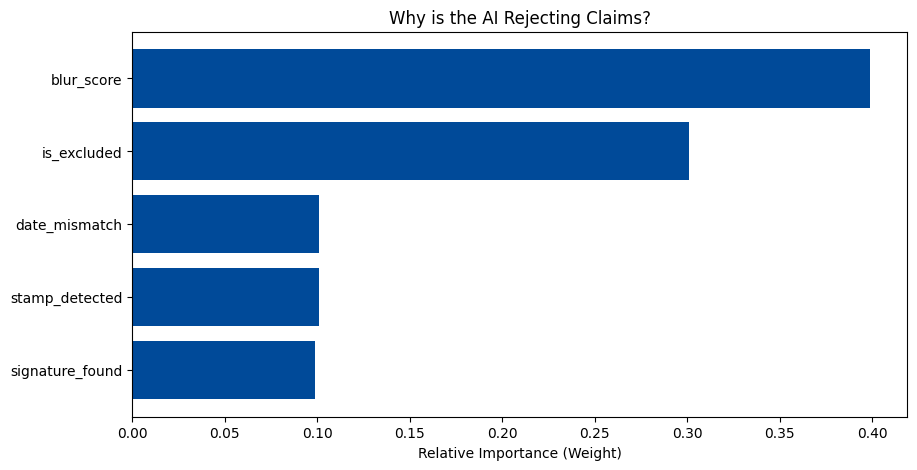


Fixed Prediction: APPROVE (Confidence: 100.0%) 
# This output no longer shows the feature warning as the input is correctly formatted.


In [ ]:
import matplotlib.pyplot as plt # Matplotlib for plotting graphs

# --- FIXING THE WARNING ---
# The previous predict_claim_readiness function caused a warning because it was passed a NumPy array
# instead of a DataFrame with feature names (which the model was trained with).
# This updated function passes a DataFrame with explicit column names.
def predict_claim_readiness(blur, stamp, sign, date_err, excluded):
    # Creating a small DataFrame for the input, ensuring feature names match training data
    input_data = pd.DataFrame([[blur, stamp, sign, date_err, excluded]],
                               columns=['blur_score', 'stamp_detected', 'signature_found', 'date_mismatch', 'is_excluded'])

    prediction = clf.predict(input_data)[0] # Get the predicted class
    probs = clf.predict_proba(input_data)[0] # Get probabilities for all classes
    conf = probs.max() # Get the highest probability as confidence

    status_map = {0: "REJECT", 1: "HUMAN REVIEW", 2: "APPROVE"} # Map predictions to status strings
    return status_map[prediction], conf # Return the status and confidence

# --- VISUALIZING FEATURE IMPORTANCE ---
# Feature importance shows which factors the model considers most important for its predictions.
importances = clf.feature_importances_ # Get feature importances from the trained RandomForest model
feature_names = X.columns # Get the names of the features
indices = np.argsort(importances) # Get indices that would sort importances in ascending order

plt.figure(figsize=(10, 5)) # Set the size of the plot
plt.title("Why is the AI Rejecting Claims?") # Set the plot title
# Create a horizontal bar chart showing feature importances
plt.barh(range(len(indices)), importances[indices], color='#004a99', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices]) # Set y-axis labels to feature names
plt.xlabel("Relative Importance (Weight)") # Set x-axis label
plt.show() # Display the plot

# Test the fixed prediction function again
status, confidence = predict_claim_readiness(0.85, 1, 1, 0, 0)
print(f"\nFixed Prediction: {status} (Confidence: {confidence*100:.1f}%) \n# This output no longer shows the feature warning as the input is correctly formatted.")
